# ISLES'22 Veri Kesfi - Parca 1

`PLAN.md` Bolum 2'deki 9 olcumu uretmek icin. Bu notebook **hicbir sey degistirmez**,
sadece olcer ve `ozet/` altina yazar.

Olculecekler:
1. Voxel spacing ve matris boyutu dagilimi (DWI/ADC/FLAIR ayri)
2. DWI ile ADC ayni grid'de mi
3. FLAIR'in DWI'ya gore uzayi (kayit maliyeti)
4. Lezyon hacmi dagilimi (mL)
5. Vaka basina bagli lezyon sayisi
6. Sinif dengesizligi + bos dilim orani
7. Merkez kirilimi
8. DWI/ADC yogunluk istatistikleri
9. Bozuk/eksik vaka kontrolu

Ortami kendi tespit eder (Colab / yerel).

In [1]:
import os, glob, json, collections
from pathlib import Path

ORTAM = 'colab' if os.path.isdir('/content') else 'yerel'


def drive_bagla(nokta='/content/drive'):
    '''Colab'da Drive'i baglar. Onceki oturum koptuysa mount noktasi bayat dosyalarla
    dolu kalir ve duz mount() 'Mountpoint must not already contain files' hatasi verir;
    o durumda force_remount denenir.'''
    if ORTAM != 'colab':
        return None
    from google.colab import drive
    if os.path.ismount(nokta):
        print('Drive zaten bagli:', nokta)
        return nokta
    try:
        drive.mount(nokta)
    except ValueError as e:
        print('duz mount basarisiz (%s) -> force_remount' % e)
        drive.mount(nokta, force_remount=True)
    return nokta


drive_bagla()

PROJE = '/content/drive/MyDrive/iskemik_inme' if ORTAM == 'colab' else str(Path.cwd())
os.makedirs(PROJE, exist_ok=True)
print('PROJE:', PROJE)

# Veri kokunu otomatik bul: icinde rawdata/ ve derivatives/ olan klasor
ADAY_KOKLER = [
    os.path.join(PROJE, 'ISLES-2022'),
    '/content/ISLES-2022',
    str(Path.cwd() / 'ISLES-2022'),
    r'D:\mamografi\iskemik_inme\ISLES-2022',
]
def gecerli(p):
    return os.path.isdir(os.path.join(p, 'rawdata')) and os.path.isdir(os.path.join(p, 'derivatives'))

DATA_ROOT = next((p for p in ADAY_KOKLER if gecerli(p)), None)
print('DATA_ROOT:', DATA_ROOT)
if DATA_ROOT is None:
    print('Veri bulunamadi -> asagidaki indirme hucresini calistir.')

ortam: colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJE: /content/drive/MyDrive/iskemik_inme
DATA_ROOT: None
Veri bulunamadi -> asagidaki indirme hucresini calistir.


### Zenodo'dan indirme (yalnizca veri bulunamadiysa)

Zip Drive'a indirilir (~1,7 GB, bir kez), acilma `/content` altina yapilir - Drive'da acmak
cok yavas. Sonraki oturumlarda zip Drive'da hazir oldugu icin yalnizca acilma calisir.

In [2]:
ZIP_URL = 'https://zenodo.org/api/records/7960856/files/ISLES-2022.zip/content'
CENTER_URL = 'https://zenodo.org/api/records/7960856/files/center_ids.xlsx/content'

if DATA_ROOT is None:
    zip_dir = PROJE
    zip_yol = os.path.join(zip_dir, 'ISLES-2022.zip')
    hedef = PROJE  # ham veri de Drive'da (kullanici karari) - acilma yavas ama tek seferlik

    if not os.path.exists(zip_yol):
        print('indiriliyor ->', zip_yol)
        os.system(f'wget -q --show-progress -O "{zip_yol}" "{ZIP_URL}"')
    else:
        print('zip zaten var:', zip_yol, f'{os.path.getsize(zip_yol)/1e9:.2f} GB')

    print('aciliyor ->', hedef)
    os.system(f'unzip -q -o "{zip_yol}" -d "{hedef}"')

    # center_ids.xlsx ayri dosya
    ci = os.path.join(zip_dir, 'center_ids.xlsx')
    if not os.path.exists(ci):
        os.system(f'wget -q -O "{ci}" "{CENTER_URL}"')

    aday = [p for p in glob.glob(os.path.join(hedef, '**', 'rawdata'), recursive=True)]
    DATA_ROOT = os.path.dirname(aday[0]) if aday else hedef
    print('DATA_ROOT:', DATA_ROOT, ' gecerli:', gecerli(DATA_ROOT))

zip zaten var: /content/drive/MyDrive/iskemik_inme/ISLES-2022.zip 1.69 GB
aciliyor -> /content/drive/MyDrive/iskemik_inme
DATA_ROOT: /content/drive/MyDrive/iskemik_inme  gecerli: False


In [3]:
try:
    import nibabel as nib
except ImportError:
    os.system('pip -q install nibabel')
    import nibabel as nib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

OZET_DIR = os.path.join(PROJE, 'ozet')
os.makedirs(OZET_DIR, exist_ok=True)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
print('nibabel:', nib.__version__)
print('ozet cikti:', OZET_DIR)

nibabel: 5.4.2
ozet cikti: /content/drive/MyDrive/iskemik_inme/ozet


## 1. Dosya envanteri

Beklenen BIDS duzeni:
`rawdata/sub-strokecaseNNNN/ses-0001/*_{dwi,adc,flair}.nii.gz` +
`derivatives/sub-strokecaseNNNN/ses-0001/*_msk.nii.gz`

Dosya adlandirmasi kaynaga gore degisebilecegi icin son ek uzerinden **glob** ile araniyor,
sabit isim varsayilmiyor.

In [4]:
import re

tum = [p for p in glob.glob(os.path.join(DATA_ROOT, '**', '*'), recursive=True) if os.path.isfile(p)]
uzanti = collections.Counter(''.join(Path(p).suffixes[-2:]).lower() for p in tum)
print('DATA_ROOT:', DATA_ROOT)
print(f'toplam dosya: {len(tum)}')
for u, n in uzanti.most_common(10):
    print(f'  {u or "(uzantisiz)":15s} {n}')

# Vaka kimligi dosya YOLUNDAN regex ile cikariliyor - dizin derinligine bagimli degil.
VAKA_RE = re.compile(r'(sub-[A-Za-z0-9]+)')
vakalar = sorted({m for p in tum for m in VAKA_RE.findall(p)})
print(f'\nvaka (sub-* deseni): {len(vakalar)}')
print('ilk 3:', vakalar[:3])

if not vakalar:
    print('\n!! sub-* bulunamadi. Ilk 25 goreli yol:')
    for q in sorted(tum)[:25]:
        print('   ', os.path.relpath(q, DATA_ROOT))
    print('\nUst duzey klasorler:', sorted({Path(os.path.relpath(q, DATA_ROOT)).parts[0] for q in tum})[:20])
else:
    print(f'\n{vakalar[0]} dosyalari:')
    for q in sorted(x for x in tum if vakalar[0] in x):
        print('   ', os.path.relpath(q, DATA_ROOT))

DATA_ROOT: /content/drive/MyDrive/iskemik_inme
toplam dosya: 1688
  .nii.gz         1000
  .json           433
  .png            250
  (uzantisiz)     2
  .zip            1
  .xlsx           1
  .tsv            1

vaka (sub-* deseni): 250
ilk 3: ['sub-strokecase0001', 'sub-strokecase0002', 'sub-strokecase0003']

sub-strokecase0001 dosyalari:
    ISLES-2022/derivatives/sub-strokecase0001/ses-0001/sub-strokecase0001_ses-0001_msk.nii.gz
    ISLES-2022/derivatives/sub-strokecase0001/ses-0001/sub-strokecase0001_ses-0001_snp.png
    ISLES-2022/sub-strokecase0001/ses-0001/anat/sub-strokecase0001_ses-0001_FLAIR.json
    ISLES-2022/sub-strokecase0001/ses-0001/anat/sub-strokecase0001_ses-0001_FLAIR.nii.gz
    ISLES-2022/sub-strokecase0001/ses-0001/dwi/sub-strokecase0001_ses-0001_adc.json
    ISLES-2022/sub-strokecase0001/ses-0001/dwi/sub-strokecase0001_ses-0001_adc.nii.gz
    ISLES-2022/sub-strokecase0001/ses-0001/dwi/sub-strokecase0001_ses-0001_dwi.json
    ISLES-2022/sub-strokecase0001/ses-000

In [5]:
SERILER = ['dwi', 'adc', 'flair']
NII = [p for p in tum if p.lower().endswith('.nii.gz')]

# Her NIfTI'yi vakasina ve seri turune ata. Tur, dosya adinin son ekinden;
# maske ayrica 'derivatives' yolunda oldugu icin iki yoldan da yakalaniyor.
def seri_turu(yol):
    ad = os.path.basename(yol).lower().replace('.nii.gz', '')
    for s in SERILER:
        if ad.endswith('_' + s) or ad.endswith(s):
            return s
    if ad.endswith('_msk') or ad.endswith('mask') or 'derivatives' in yol.lower():
        return 'msk'
    return None

kayit = {v: {'vaka': v, 'dwi': None, 'adc': None, 'flair': None, 'msk': None} for v in vakalar}
coklu, siniflanamayan = [], []
for q in NII:
    v = next(iter(VAKA_RE.findall(q)), None)
    t = seri_turu(q)
    if v is None or t is None:
        siniflanamayan.append(q)
        continue
    if kayit[v][t] is not None:
        coklu.append((v, t, q))
    else:
        kayit[v][t] = q

dosya = pd.DataFrame([kayit[v] for v in vakalar])
print('vaka:', len(dosya), ' nii.gz:', len(NII))
for k in SERILER + ['msk']:
    print(f'  {k:6s} bulunan: {dosya[k].notna().sum():4d}  eksik: {dosya[k].isna().sum()}')

if siniflanamayan:
    print(f'\nsiniflanamayan {len(siniflanamayan)} dosya (ilk 5):')
    for q in siniflanamayan[:5]:
        print('   ', os.path.relpath(q, DATA_ROOT))
if coklu:
    print(f'\nayni vaka+seri icin birden fazla dosya: {len(coklu)} (ilk 5)')
    for v, t, q in coklu[:5]:
        print(f'    {v} {t}: {os.path.relpath(q, DATA_ROOT)}')

eksik = dosya[dosya[SERILER + ['msk']].isna().any(axis=1)]
if len(eksik):
    print('\nEKSIK SERISI OLAN VAKALAR:')
    print(eksik[['vaka'] + SERILER + ['msk']].notna().to_string())
else:
    print('\nEksik seri yok.')

vaka: 250  nii.gz: 1000
  dwi    bulunan:  250  eksik: 0
  adc    bulunan:  250  eksik: 0
  flair  bulunan:  250  eksik: 0
  msk    bulunan:  250  eksik: 0

Eksik seri yok.


## 2. Header taramasi - olcum 1, 2, 3

Piksel okunmuyor, sadece header. Her seri icin sekil, spacing ve affine aliniyor.
DWI ile ADC'nin **ayni grid'de** olup olmadigi burada kesinlesiyor - iki kanal
birlestirmenin on sarti bu.

In [6]:
def hdr(yol):
    if yol is None:
        return None
    im = nib.load(yol)
    return dict(sekil=tuple(int(x) for x in im.shape),
                spacing=tuple(round(float(z), 4) for z in im.header.get_zooms()[:3]),
                dtype=str(im.get_data_dtype()),
                affine=im.affine)

satir = []
for _, r in dosya.iterrows():
    d = {'vaka': r.vaka}
    h = {}
    for k in SERILER + ['msk']:
        h[k] = hdr(r[k])
        if h[k]:
            d[f'{k}_sekil'] = 'x'.join(map(str, h[k]['sekil']))
            d[f'{k}_spacing'] = 'x'.join(f'{z:g}' for z in h[k]['spacing'])
            d[f'{k}_dtype'] = h[k]['dtype']
    # olcum 2: DWI vs ADC ayni grid mi
    if h['dwi'] and h['adc']:
        d['dwi_adc_ayni_sekil'] = h['dwi']['sekil'] == h['adc']['sekil']
        d['dwi_adc_ayni_affine'] = bool(np.allclose(h['dwi']['affine'], h['adc']['affine'], atol=1e-4))
    # maske DWI grid'inde mi
    if h['dwi'] and h['msk']:
        d['msk_dwi_ayni_sekil'] = h['dwi']['sekil'] == h['msk']['sekil']
        d['msk_dwi_ayni_affine'] = bool(np.allclose(h['dwi']['affine'], h['msk']['affine'], atol=1e-4))
    # olcum 3: FLAIR uzayi
    if h['dwi'] and h['flair']:
        d['flair_dwi_ayni_sekil'] = h['dwi']['sekil'] == h['flair']['sekil']
        d['flair_dwi_ayni_affine'] = bool(np.allclose(h['dwi']['affine'], h['flair']['affine'], atol=1e-4))
        d['flair_voxel_mm3'] = round(float(np.prod(h['flair']['spacing'])), 4)
        d['dwi_voxel_mm3'] = round(float(np.prod(h['dwi']['spacing'])), 4)
    satir.append(d)

meta = pd.DataFrame(satir)
print(meta.shape)
meta.head(3).T

(250, 21)


,0,1,2
vaka,sub-strokecase0001,sub-strokecase0002,sub-strokecase0003
dwi_sekil,112x112x73,112x112x72,112x112x72
dwi_spacing,2x2x2,2x2x2,2x2x2
dwi_dtype,float64,float64,float64
adc_sekil,112x112x73,112x112x72,112x112x72
adc_spacing,2x2x2,2x2x2,2x2x2
adc_dtype,float64,float64,float64
flair_sekil,281x352x352,281x352x352,281x352x352
flair_spacing,0.7115x0.7102x0.7102,0.7115x0.7102x0.7102,0.7115x0.7102x0.7102
flair_dtype,float32,float32,float32


In [7]:
print('--- olcum 1: matris boyutu ve spacing dagilimi ---')
for k in SERILER:
    print(f'\n[{k}] sekil (ilk 8):')
    print(meta[f'{k}_sekil'].value_counts().head(8).to_string())
    print(f'[{k}] spacing (ilk 8):')
    print(meta[f'{k}_spacing'].value_counts().head(8).to_string())
    print(f'[{k}] farkli sekil sayisi: {meta[f"{k}_sekil"].nunique()}'
          f'  farkli spacing sayisi: {meta[f"{k}_spacing"].nunique()}')

print('\n--- olcum 2: DWI ile ADC ayni grid mi ---')
print('ayni sekil :', int(meta.dwi_adc_ayni_sekil.sum()), '/', len(meta))
print('ayni affine:', int(meta.dwi_adc_ayni_affine.sum()), '/', len(meta))
print('maske DWI grid (sekil):', int(meta.msk_dwi_ayni_sekil.sum()), '/', len(meta))
print('maske DWI grid (affine):', int(meta.msk_dwi_ayni_affine.sum()), '/', len(meta))
kotu = meta[~meta.dwi_adc_ayni_affine.fillna(False)]
if len(kotu):
    print('\nDWI-ADC affine UYUSMAYAN vakalar:')
    print(kotu[['vaka', 'dwi_sekil', 'adc_sekil', 'dwi_spacing', 'adc_spacing']].to_string(index=False))

print('\n--- olcum 3: FLAIR uzayi ---')
print('FLAIR sekil = DWI sekil :', int(meta.flair_dwi_ayni_sekil.sum()), '/', len(meta))
print('FLAIR affine = DWI affine:', int(meta.flair_dwi_ayni_affine.sum()), '/', len(meta))
print('\nvoxel hacmi (mm3) ozeti:')
print(meta[['dwi_voxel_mm3', 'flair_voxel_mm3']].describe().to_string())
print('\nYorum: FLAIR affine uyusmuyorsa kullanmak icin her vakada kayit (registration) gerekir;'
      ' maliyeti Bolum 3 gecikme butcesine yazilir (ablasyon A1).')

--- olcum 1: matris boyutu ve spacing dagilimi ---

[dwi] sekil (ilk 8):
dwi_sekil
112x112x73    93
112x112x72    92
128x128x25    27
192x192x30    23
128x128x72     2
256x256x73     2
115x115x75     1
115x115x28     1
[dwi] spacing (ilk 8):
dwi_spacing
2x2x2                193
1.7969x1.7969x4.8     29
1.1458x1.1458x4.8     23
0.875x0.875x2          2
2x2x5                  1
1.3529x1.3529x4.4      1
1.9672x1.9672x2        1
[dwi] farkli sekil sayisi: 17  farkli spacing sayisi: 7

[adc] sekil (ilk 8):
adc_sekil
112x112x73    93
112x112x72    92
128x128x25    27
192x192x30    23
128x128x72     2
256x256x73     2
115x115x75     1
115x115x28     1
[adc] spacing (ilk 8):
adc_spacing
2x2x2                193
1.7969x1.7969x4.8     29
1.1458x1.1458x4.8     23
0.875x0.875x2          2
2x2x5                  1
1.3529x1.3529x4.4      1
1.9672x1.9672x2        1
[adc] farkli sekil sayisi: 17  farkli spacing sayisi: 7

[flair] sekil (ilk 8):
flair_sekil
281x352x352    112
512x512x29      30
224x256

## 3. Merkez kirilimi - olcum 7

`center_ids.xlsx` vaka -> merkez eslesmesini verir. Split bu eksende stratifiye edilecek.

In [8]:
ci_adaylar = (glob.glob(os.path.join(DATA_ROOT, '**', 'center_ids.xlsx'), recursive=True)
              + glob.glob(os.path.join(PROJE, 'center_ids.xlsx'))
              + glob.glob(os.path.join(os.path.dirname(DATA_ROOT), 'center_ids.xlsx')))
CENTER_YOL = ci_adaylar[0] if ci_adaylar else None
print('center_ids.xlsx:', CENTER_YOL)

if CENTER_YOL:
    merkez = pd.read_excel(CENTER_YOL)
    print(merkez.shape, list(merkez.columns))
    print(merkez.head().to_string(index=False))
    # vaka kolonunu tahmin et
    vk = next((c for c in merkez.columns if merkez[c].astype(str).str.contains('sub-').any()), merkez.columns[0])
    mk = next((c for c in merkez.columns if c != vk), merkez.columns[-1])
    merkez = merkez.rename(columns={vk: 'vaka', mk: 'merkez'})[['vaka', 'merkez']]
    merkez['vaka'] = merkez.vaka.astype(str)
    meta = meta.merge(merkez, on='vaka', how='left')
    print('\nmerkez dagilimi:')
    print(meta.merkez.value_counts(dropna=False).to_string())
    print('eslesmeyen vaka:', int(meta.merkez.isna().sum()))
else:
    meta['merkez'] = np.nan
    print('center_ids.xlsx bulunamadi -> merkez stratifikasyonu yapilamaz, split yalniz hacme gore.')

center_ids.xlsx: /content/drive/MyDrive/iskemik_inme/center_ids.xlsx
(250, 2) ['case', 'center']
              case  center
sub-strokecase0001       1
sub-strokecase0002       1
sub-strokecase0003       1
sub-strokecase0004       1
sub-strokecase0005       1

merkez dagilimi:
merkez
1    198
2     52
eslesmeyen vaka: 0


## 4. Lezyon istatistikleri - olcum 4, 5, 6

Bu hucre **250 maskenin tamamini okur** (maskeler kucuk, birkac dakika). Uretilenler:
hacim (mL), bagli lezyon sayisi, lezyonlu/bos dilim orani, beyin ici lezyon voxel orani.

Beyin maskesi kaba: DWI > (p99 x 0.05). Amac tam beyin segmentasyonu degil, sinif
dengesizligi orani icin makul bir payda.

In [9]:
def vaka_olc(r):
    mi = nib.load(r.msk)
    m = np.asarray(mi.dataobj) > 0.5
    zoom = mi.header.get_zooms()[:3]
    voxel_ml = float(np.prod(zoom)) / 1000.0

    di = nib.load(r.dwi)
    dw = np.asarray(di.dataobj).astype(np.float32)
    esik = np.percentile(dw, 99) * 0.05
    beyin = dw > esik

    # 26-komsuluk bagli bilesen
    etiket, n = ndimage.label(m, structure=np.ones((3, 3, 3)))
    boyutlar = np.bincount(etiket.ravel())[1:] if n else np.array([])

    # dilim ekseni: en kucuk boyut (aksiyel varsayimi Parca 1'de dogrulaniyor)
    z = int(np.argmin(m.shape))
    dilim_lez = m.any(axis=tuple(i for i in range(3) if i != z))
    dilim_bey = beyin.any(axis=tuple(i for i in range(3) if i != z))

    return dict(
        vaka=r.vaka,
        hacim_ml=float(m.sum()) * voxel_ml,
        voxel=int(m.sum()),
        lezyon_sayisi=int(n),
        en_buyuk_ml=float(boyutlar.max()) * voxel_ml if n else 0.0,
        kucuk_bilesen_5vox=int((boyutlar < 5).sum()) if n else 0,
        dilim_toplam=int(m.shape[z]),
        dilim_lezyonlu=int(dilim_lez.sum()),
        dilim_beyin=int(dilim_bey.sum()),
        bos_dilim_orani=float(1 - dilim_lez.sum() / max(dilim_bey.sum(), 1)),
        lezyon_voxel_orani=float(m.sum() / max(beyin.sum(), 1)),
        bos_maske=bool(m.sum() == 0),
        dilim_ekseni=z,
    )

lez = []
for i, r in dosya.dropna(subset=['msk', 'dwi']).iterrows():
    try:
        lez.append(vaka_olc(r))
    except Exception as e:
        print('HATA', r.vaka, repr(e))
    if (len(lez)) % 50 == 0:
        print(f'  {len(lez)}/{len(dosya)}')

lezyon = pd.DataFrame(lez).merge(meta[['vaka', 'merkez']], on='vaka', how='left')
print('\nolculen vaka:', len(lezyon))
lezyon.head(3)

  50/250
  100/250
  150/250
  200/250
  250/250

olculen vaka: 250


,vaka,hacim_ml,voxel,lezyon_sayisi,en_buyuk_ml,kucuk_bilesen_5vox,dilim_toplam,dilim_lezyonlu,dilim_beyin,bos_dilim_orani,lezyon_voxel_orani,bos_maske,dilim_ekseni,merkez
0,sub-strokecase0001,6.680,835,31,1.392,5,73,45,65,0.307692,0.005722,False,2,1
1,sub-strokecase0002,0.944,118,1,0.944,0,72,8,63,0.873016,0.000816,False,2,1
2,sub-strokecase0003,30.984,3873,46,29.056,23,72,43,69,0.376812,0.021477,False,2,1


In [10]:
print('--- olcum 4: lezyon hacmi (mL) ---')
print(lezyon.hacim_ml.describe(percentiles=[.05, .25, .5, .75, .95]).to_string())
print('bos maske (hacim=0):', int(lezyon.bos_maske.sum()))
print('1 mL alti:', int((lezyon.hacim_ml < 1).sum()),
      ' 5 mL alti:', int((lezyon.hacim_ml < 5).sum()),
      ' 50 mL ustu:', int((lezyon.hacim_ml > 50).sum()))

print('\n--- olcum 5: bagli lezyon sayisi ---')
print(lezyon.lezyon_sayisi.value_counts().sort_index().head(15).to_string())
print('cok odakli (>1) vaka orani:', f'{(lezyon.lezyon_sayisi > 1).mean():.3f}')
print('5 voxel altindaki bilesen toplami:', int(lezyon.kucuk_bilesen_5vox.sum()))

print('\n--- olcum 6: sinif dengesizligi ve bos dilim ---')
print('lezyon voxel / beyin voxel:')
print(lezyon.lezyon_voxel_orani.describe().to_string())
print(f'ortalama: {lezyon.lezyon_voxel_orani.mean()*100:.3f}%')
print('\nbos dilim orani (beyin iceren dilimler icinde):')
print(lezyon.bos_dilim_orani.describe().to_string())
print('\ndilim ekseni dagilimi (0=x,1=y,2=z):', lezyon.dilim_ekseni.value_counts().to_dict())

print('\n--- olcum 7: merkez x hacim ---')
if lezyon.merkez.notna().any():
    print(lezyon.groupby('merkez').hacim_ml.agg(['count', 'median', 'mean', 'std']).to_string())

--- olcum 4: lezyon hacmi (mL) ---
count    250.000000
mean      23.423520
std       46.998367
min        0.000000
5%         0.195600
25%        1.576824
50%        6.656582
75%       21.170277
95%      109.615816
max      482.152000
bos maske (hacim=0): 3
1 mL alti: 46  5 mL alti: 104  50 mL ustu: 30

--- olcum 5: bagli lezyon sayisi ---
lezyon_sayisi
0      3
1     48
2     26
3     22
4     18
5     13
6     15
7     11
8     10
9     10
10     9
11     5
12     7
13     5
14     5
cok odakli (>1) vaka orani: 0.796
5 voxel altindaki bilesen toplami: 897

--- olcum 6: sinif dengesizligi ve bos dilim ---
lezyon voxel / beyin voxel:
count    250.000000
mean       0.017781
std        0.037031
min        0.000000
25%        0.001175
50%        0.005331
75%        0.016353
max        0.363458
ortalama: 1.778%

bos dilim orani (beyin iceren dilimler icinde):
count    250.000000
mean       0.648788
std        0.208559
min        0.040000
25%        0.507581
50%        0.678462
75%        0

## 5. Yogunluk istatistikleri - olcum 8

DWI keyfi olcekte, ADC fizik birimli (x10^-6 mm2/s). Ayri normalize edilecekleri buradan
kesinlesiyor. Tum veriyi okumamak icin sabit seed ile 40 vaka.

In [11]:
rng = np.random.default_rng(42)
alt = dosya.dropna(subset=['dwi', 'adc']).sample(min(40, len(dosya)), random_state=42)

yog = []
for _, r in alt.iterrows():
    dw = np.asarray(nib.load(r.dwi).dataobj).astype(np.float32)
    ad = np.asarray(nib.load(r.adc).dataobj).astype(np.float32)
    esik = np.percentile(dw, 99) * 0.05
    b = dw > esik
    yog.append(dict(
        vaka=r.vaka,
        dwi_min=float(dw.min()), dwi_max=float(dw.max()),
        dwi_p1=float(np.percentile(dw[b], 1)), dwi_p99=float(np.percentile(dw[b], 99)),
        dwi_ort=float(dw[b].mean()), dwi_std=float(dw[b].std()),
        adc_min=float(ad.min()), adc_max=float(ad.max()),
        adc_p1=float(np.percentile(ad[b], 1)), adc_p99=float(np.percentile(ad[b], 99)),
        adc_ort=float(ad[b].mean()), adc_std=float(ad[b].std()),
        beyin_orani=float(b.mean()),
        nan_var=bool(np.isnan(dw).any() or np.isnan(ad).any()),
    ))
yogunluk = pd.DataFrame(yog)
print(yogunluk.drop(columns=['vaka']).describe().to_string())
print('\nNaN iceren vaka:', int(yogunluk.nan_var.sum()))
print('\nYorum: DWI p99 vakalar arasi cok oynuyorsa per-vaka z-score sart;'
      ' ADC p99 sabite yakinsa sabit klip dogru secim.')

            dwi_min      dwi_max     dwi_p1     dwi_p99     dwi_ort     dwi_std     adc_min      adc_max      adc_p1      adc_p99      adc_ort     adc_std  beyin_orani
count  4.000000e+01    40.000000  40.000000   40.000000   40.000000   40.000000   40.000000    40.000000   40.000000    40.000000    40.000000   40.000000    40.000000
mean  -8.277192e+00  1239.723190  29.801457  389.650811  194.774901   77.132018  -34.209217  1359.775588   85.846768  1162.856296   427.890527  254.400883     0.188036
std    1.105159e+01   492.499764  10.872592  133.237962   56.296205   22.899340  150.737013  1985.373848  156.756993  1704.185864   628.308676  372.825840     0.025475
min   -4.780590e+01   311.000000   8.001007  124.997948   68.550652   25.563580 -699.474304     0.003561    0.000000     0.002890     0.000990    0.000515     0.138923
25%   -1.467553e+01   870.671616  23.971245  322.342026  169.944683   63.421413   -0.196904     0.004303    0.000413     0.003367     0.001305    0.000717     0

## 6. Butunluk kontrolu - olcum 9

Egitime giremeyecek vakalar burada listeleniyor. Parca 2 bu listeyi okuyup disliyor.

In [12]:
sorun = []
for _, r in meta.iterrows():
    n = []
    if r.get('dwi_adc_ayni_sekil') is False: n.append('dwi-adc sekil uyusmuyor')
    if r.get('msk_dwi_ayni_sekil') is False: n.append('maske-dwi sekil uyusmuyor')
    if n:
        sorun.append(dict(vaka=r.vaka, neden='; '.join(n)))

for _, r in lezyon.iterrows():
    if r.bos_maske:
        sorun.append(dict(vaka=r.vaka, neden='bos maske (lezyon yok)'))

for _, r in dosya.iterrows():
    y = [k for k in ['dwi', 'adc', 'msk'] if r[k] is None]
    if y:
        sorun.append(dict(vaka=r.vaka, neden='eksik seri: ' + ','.join(y)))

sorunlu = pd.DataFrame(sorun)
if len(sorunlu):
    print(sorunlu.groupby('neden').size().to_string())
    print('\netkilenen benzersiz vaka:', sorunlu.vaka.nunique())
    print(sorunlu.to_string(index=False))
else:
    print('Sorunlu vaka yok.')

haric = sorted(sorunlu.vaka.unique()) if len(sorunlu) else []
with open(os.path.join(OZET_DIR, 'haric_vakalar.json'), 'w', encoding='utf-8') as f:
    json.dump({'vakalar': haric,
               'gerekce': 'Parca 1 butunluk kontrolu: eksik seri / grid uyusmazligi / bos maske.',
               'detay': sorun}, f, indent=2, ensure_ascii=False)
print('\nharic_vakalar.json yazildi:', len(haric), 'vaka')

neden
bos maske (lezyon yok)    3

etkilenen benzersiz vaka: 3
              vaka                  neden
sub-strokecase0150 bos maske (lezyon yok)
sub-strokecase0151 bos maske (lezyon yok)
sub-strokecase0170 bos maske (lezyon yok)

haric_vakalar.json yazildi: 3 vaka


## 7. Grafikler

/tmp/ipykernel_7524/3263924910.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot(gr, labels=[str(k) for k, _ in lezyon.groupby('merkez')])


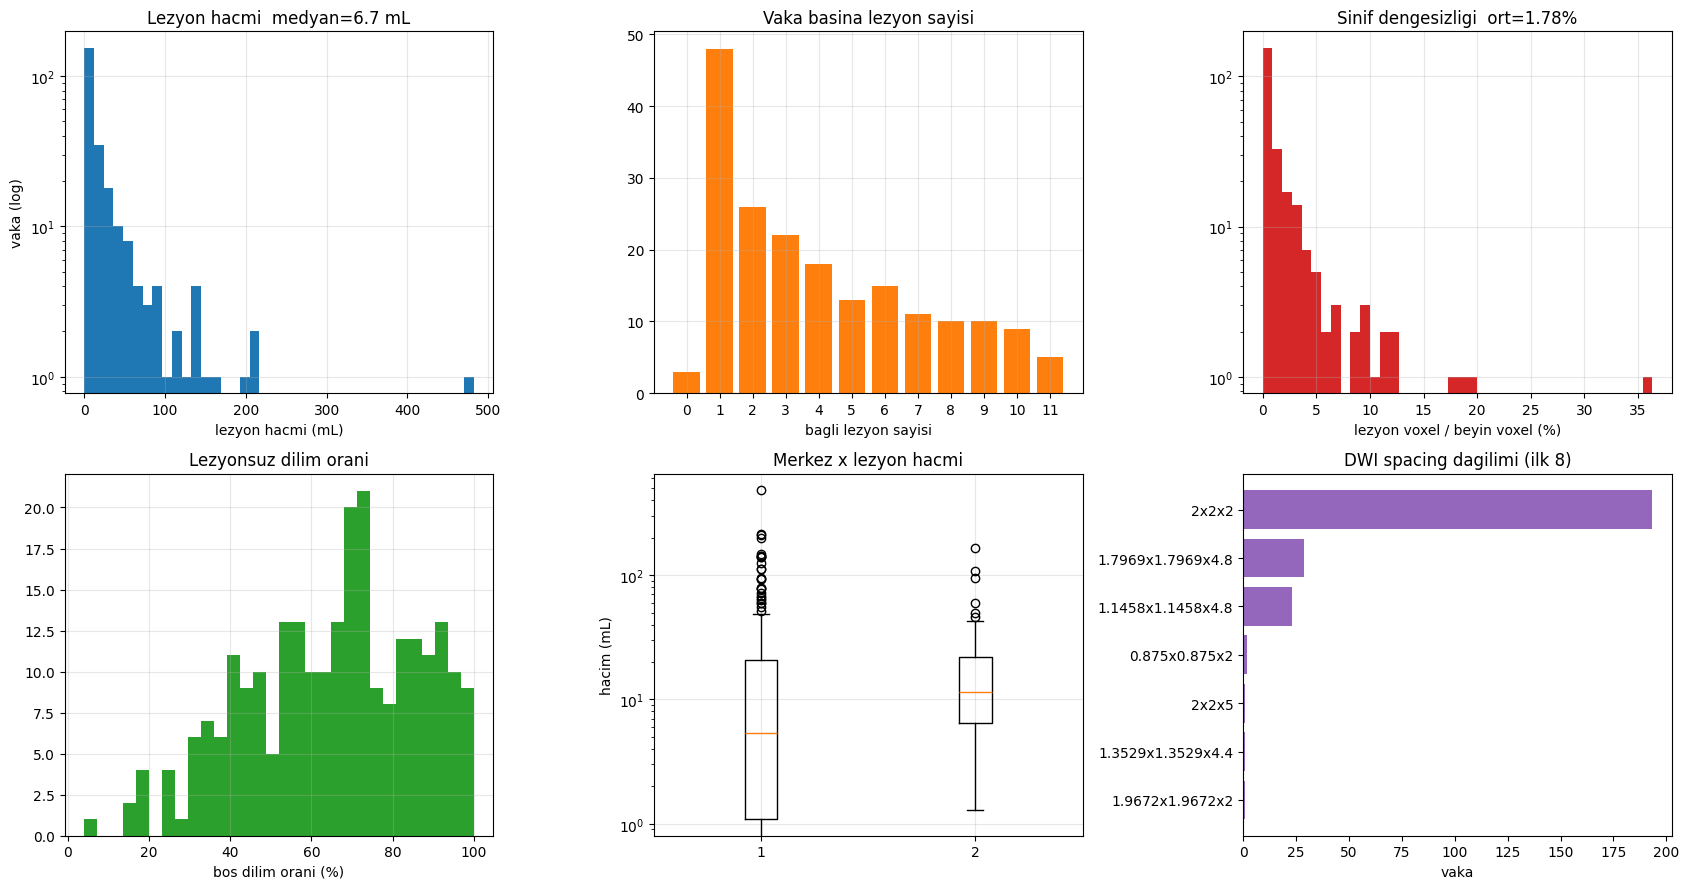

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(17, 9))

a = ax[0, 0]
a.hist(lezyon.hacim_ml, bins=40, color='tab:blue')
a.set_yscale('log'); a.set_xlabel('lezyon hacmi (mL)'); a.set_ylabel('vaka (log)')
a.set_title(f'Lezyon hacmi  medyan={lezyon.hacim_ml.median():.1f} mL'); a.grid(alpha=.3)

a = ax[0, 1]
s = lezyon.lezyon_sayisi.value_counts().sort_index().head(12)
a.bar(s.index.astype(str), s.values, color='tab:orange')
a.set_xlabel('bagli lezyon sayisi'); a.set_title('Vaka basina lezyon sayisi'); a.grid(alpha=.3)

a = ax[0, 2]
a.hist(lezyon.lezyon_voxel_orani * 100, bins=40, color='tab:red')
a.set_xlabel('lezyon voxel / beyin voxel (%)'); a.set_yscale('log')
a.set_title(f'Sinif dengesizligi  ort={lezyon.lezyon_voxel_orani.mean()*100:.2f}%'); a.grid(alpha=.3)

a = ax[1, 0]
a.hist(lezyon.bos_dilim_orani * 100, bins=30, color='tab:green')
a.set_xlabel('bos dilim orani (%)'); a.set_title('Lezyonsuz dilim orani'); a.grid(alpha=.3)

a = ax[1, 1]
if lezyon.merkez.notna().any():
    gr = [g.hacim_ml.values for _, g in lezyon.groupby('merkez')]
    a.boxplot(gr, labels=[str(k) for k, _ in lezyon.groupby('merkez')])
    a.set_yscale('log'); a.set_ylabel('hacim (mL)'); a.set_title('Merkez x lezyon hacmi')
else:
    a.text(.5, .5, 'merkez bilgisi yok', ha='center'); a.set_axis_off()
a.grid(alpha=.3)

a = ax[1, 2]
sp = meta.dwi_spacing.value_counts().head(8)
a.barh(sp.index[::-1].astype(str), sp.values[::-1], color='tab:purple')
a.set_title('DWI spacing dagilimi (ilk 8)'); a.set_xlabel('vaka')

plt.tight_layout()
plt.savefig(os.path.join(OZET_DIR, 'veri_kesfi.png'), dpi=130, bbox_inches='tight')
plt.show()

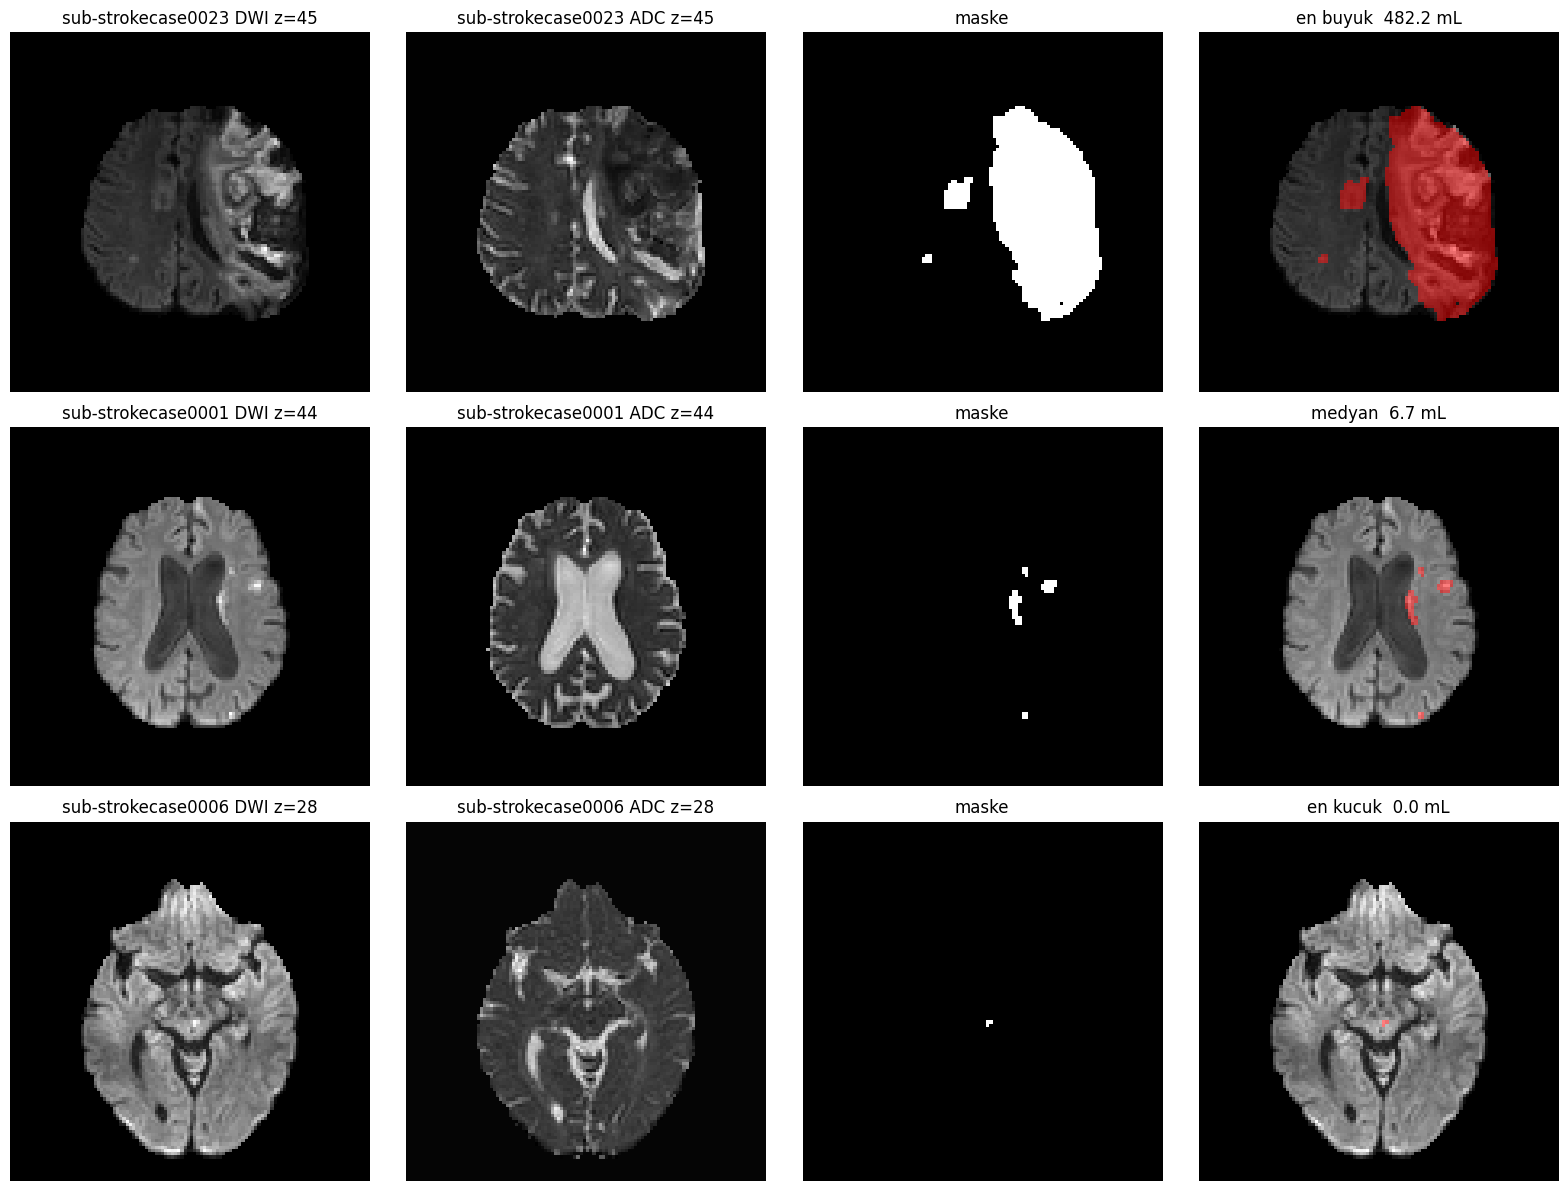

In [14]:
# Ornek vakalar: en buyuk / medyan / en kucuk lezyon
sec = [lezyon.hacim_ml.idxmax(),
       (lezyon.hacim_ml - lezyon.hacim_ml.median()).abs().idxmin(),
       lezyon[lezyon.hacim_ml > 0].hacim_ml.idxmin()]
basliklar = ['en buyuk', 'medyan', 'en kucuk']

fig, ax = plt.subplots(len(sec), 4, figsize=(16, 4 * len(sec)))
for i, (idx, bas) in enumerate(zip(sec, basliklar)):
    v = lezyon.loc[idx, 'vaka']
    r = dosya[dosya.vaka == v].iloc[0]
    dw = np.asarray(nib.load(r.dwi).dataobj).astype(np.float32)
    ad = np.asarray(nib.load(r.adc).dataobj).astype(np.float32)
    m = np.asarray(nib.load(r.msk).dataobj) > .5
    z = int(lezyon.loc[idx, 'dilim_ekseni'])
    dw, ad, m = [np.moveaxis(x, z, -1) for x in (dw, ad, m)]
    k = int(np.argmax(m.sum(axis=(0, 1))))  # en cok lezyon iceren dilim

    for j, (img, t) in enumerate([(dw[..., k], 'DWI'), (ad[..., k], 'ADC')]):
        ax[i, j].imshow(img.T, cmap='gray', origin='lower'); ax[i, j].set_title(f'{v} {t} z={k}')
    ax[i, 2].imshow(m[..., k].T, cmap='gray', origin='lower'); ax[i, 2].set_title('maske')
    ax[i, 3].imshow(dw[..., k].T, cmap='gray', origin='lower')
    ax[i, 3].imshow(np.ma.masked_where(~m[..., k].T, m[..., k].T), cmap='autumn', alpha=.5, origin='lower')
    ax[i, 3].set_title(f'{bas}  {lezyon.loc[idx, "hacim_ml"]:.1f} mL')
    for j in range(4):
        ax[i, j].set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(OZET_DIR, 'ornek_vakalar.png'), dpi=130, bbox_inches='tight')
plt.show()

## 8. Ozet - `PLAN.md` Bolum 2'ye islenecek satirlar

In [15]:
ozet = {
    'ortam': ORTAM,
    'data_root': DATA_ROOT,
    'vaka_sayisi': len(dosya),
    'tam_vaka': int(dosya[SERILER + ['msk']].notna().all(axis=1).sum()),
    'haric_vaka': len(haric),
    # olcum 1
    'dwi_sekil_cesidi': int(meta.dwi_sekil.nunique()),
    'dwi_sekil_en_sik': meta.dwi_sekil.mode()[0],
    'dwi_spacing_cesidi': int(meta.dwi_spacing.nunique()),
    'dwi_spacing_en_sik': meta.dwi_spacing.mode()[0],
    'flair_sekil_cesidi': int(meta.flair_sekil.nunique()),
    'flair_spacing_en_sik': meta.flair_spacing.mode()[0],
    # olcum 2
    'dwi_adc_ayni_grid': f'{int(meta.dwi_adc_ayni_affine.sum())}/{len(meta)}',
    'maske_dwi_ayni_grid': f'{int(meta.msk_dwi_ayni_affine.sum())}/{len(meta)}',
    # olcum 3
    'flair_dwi_ayni_grid': f'{int(meta.flair_dwi_ayni_affine.sum())}/{len(meta)}',
    'flair_kayit_gerekli': bool(meta.flair_dwi_ayni_affine.sum() < len(meta)),
    # olcum 4
    'hacim_ml_medyan': round(float(lezyon.hacim_ml.median()), 2),
    'hacim_ml_iqr': [round(float(lezyon.hacim_ml.quantile(.25)), 2),
                     round(float(lezyon.hacim_ml.quantile(.75)), 2)],
    'hacim_ml_min_max': [round(float(lezyon.hacim_ml.min()), 3), round(float(lezyon.hacim_ml.max()), 1)],
    'hacim_1ml_alti_vaka': int((lezyon.hacim_ml < 1).sum()),
    # olcum 5
    'cok_odakli_oran': round(float((lezyon.lezyon_sayisi > 1).mean()), 3),
    'lezyon_sayisi_medyan': int(lezyon.lezyon_sayisi.median()),
    # olcum 6
    'lezyon_voxel_orani_ort': round(float(lezyon.lezyon_voxel_orani.mean()), 5),
    'bos_dilim_orani_ort': round(float(lezyon.bos_dilim_orani.mean()), 3),
    # olcum 7
    'merkez_dagilimi': meta.merkez.value_counts(dropna=False).to_dict() if meta.merkez.notna().any() else None,
    # olcum 8
    'dwi_p99_ort': round(float(yogunluk.dwi_p99.mean()), 1),
    'dwi_p99_std': round(float(yogunluk.dwi_p99.std()), 1),
    'adc_p99_ort': round(float(yogunluk.adc_p99.mean()), 1),
    'adc_p99_std': round(float(yogunluk.adc_p99.std()), 1),
    'beyin_orani_ort': round(float(yogunluk.beyin_orani.mean()), 3),
}
for k, v in ozet.items():
    print(f'{k:26s} {v}')

with open(os.path.join(OZET_DIR, 'kesif_ozeti.json'), 'w', encoding='utf-8') as f:
    json.dump(ozet, f, indent=2, ensure_ascii=False, default=str)

with pd.ExcelWriter(os.path.join(OZET_DIR, 'kesif_ozeti.xlsx')) as w:
    pd.DataFrame([{'olcum': k, 'deger': str(v)} for k, v in ozet.items()]).to_excel(w, 'ozet', index=False)
    meta.drop(columns=[c for c in meta.columns if c.endswith('affine')], errors='ignore').to_excel(w, 'vaka_meta', index=False)
    lezyon.to_excel(w, 'lezyon', index=False)
    yogunluk.to_excel(w, 'yogunluk', index=False)
    if len(sorunlu):
        sorunlu.to_excel(w, 'sorunlu', index=False)

print('\nyazildi:', OZET_DIR)
print(' - kesif_ozeti.json / kesif_ozeti.xlsx')
print(' - haric_vakalar.json')
print(' - veri_kesfi.png / ornek_vakalar.png')

ortam                      colab
data_root                  /content/drive/MyDrive/iskemik_inme
vaka_sayisi                250
tam_vaka                   250
haric_vaka                 3
dwi_sekil_cesidi           17
dwi_sekil_en_sik           112x112x73
dwi_spacing_cesidi         7
dwi_spacing_en_sik         2x2x2
flair_sekil_cesidi         22
flair_spacing_en_sik       0.7115x0.7102x0.7102
dwi_adc_ayni_grid          250/250
maske_dwi_ayni_grid        250/250
flair_dwi_ayni_grid        0/250
flair_kayit_gerekli        True
hacim_ml_medyan            6.66
hacim_ml_iqr               [1.58, 21.17]
hacim_ml_min_max           [0.0, 482.2]
hacim_1ml_alti_vaka        46
cok_odakli_oran            0.796
lezyon_sayisi_medyan       5
lezyon_voxel_orani_ort     0.01778
bos_dilim_orani_ort        0.649
merkez_dagilimi            {1: 198, 2: 52}
dwi_p99_ort                389.7
dwi_p99_std                133.2
adc_p99_ort                1162.9
adc_p99_std                1704.2
beyin_orani_ort     

/tmp/ipykernel_7524/2948977599.py:48: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  pd.DataFrame([{'olcum': k, 'deger': str(v)} for k, v in ozet.items()]).to_excel(w, 'ozet', index=False)
/tmp/ipykernel_7524/2948977599.py:49: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  meta.drop(columns=[c for c in meta.columns if c.endswith('affine')], errors='ignore').to_excel(w, 'vaka_meta', index=False)
/tmp/ipykernel_7524/2948977599.py:50: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  lezyon.to_excel(w, 'lezyon', index=False)



yazildi: /content/drive/MyDrive/iskemik_inme/ozet
 - kesif_ozeti.json / kesif_ozeti.xlsx
 - haric_vakalar.json
 - veri_kesfi.png / ornek_vakalar.png


/tmp/ipykernel_7524/2948977599.py:51: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  yogunluk.to_excel(w, 'yogunluk', index=False)
/tmp/ipykernel_7524/2948977599.py:53: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  sorunlu.to_excel(w, 'sorunlu', index=False)
